In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression
import xgboost as xgb
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, cross_val_score
from sklearn.svm import SVR
from sklearn.neighbors import NearestNeighbors
from concurrent.futures import ProcessPoolExecutor

In [28]:
df = pd.read_csv(r'C:\Users\Faculty\Desktop\Manoj_Honors\Merged_Data.csv')
df.columns

Index(['From Date', 'Stn_id', 'NO2', 'PM2.5', 'O3', 'Station', 'Lat', 'Lon'], dtype='object')

In [12]:
# Load the CSV file
file_path = r"D:\Manoj_Honors\Merged_NO2.csv"
df = pd.read_csv(file_path)

# Reshape the data using `melt`
df_long = pd.melt(df, id_vars=['From Date'],
                  value_vars=[str(i) for i in range(40)],
                  var_name='Stn_id',
                  value_name='NO2')

# Save the modified file
output_file_path = r"D:\Manoj_Honors\Merged_NO2.csv"
df_long.to_csv(output_file_path, index=False)

print(f"Reshaped file saved as {output_file_path}")


Reshaped file saved as D:\Manoj_Honors\Merged_NO2.csv


In [15]:
import pandas as pd

# Load the CSV file
file_path = r"D:\Manoj_Honors\Merged_O3.csv"  # Replace with your file path
df = pd.read_csv(file_path)

# Ensure 'From Date' is in a datetime format
df['From Date'] = pd.to_datetime(df['From Date'], errors='coerce')

# Sort the dataframe by 'From Date' and then by 'stn-id'
sorted_df = df.sort_values(by=['From Date', 'Stn_id'])

# Save the sorted data to a new CSV file
output_path = r"D:\Manoj_Honors\Merged_O3.csv"  # Replace with your desired output path
sorted_df.to_csv(output_path, index=False)

print(f"File sorted by 'From Date' and 'stn-id' and saved to {output_path}")



File sorted by 'From Date' and 'stn-id' and saved to D:\Manoj_Honors\Merged_O3.csv


In [15]:
import pandas as pd

# File paths
no2_file = r"D:\Manoj_Honors\Merged_NO2.csv"
pm25_file = r"D:\Manoj_Honors\Merged_PM2.5.csv"
o3_file = r"D:\Manoj_Honors\Merged_O3.csv"

# Load the data
no2_df = pd.read_csv(no2_file)
pm25_df = pd.read_csv(pm25_file)
o3_df = pd.read_csv(o3_file)

# Ensure 'From Date' is in datetime format for all dataframes
no2_df['From Date'] = pd.to_datetime(no2_df['From Date'], errors='coerce')
pm25_df['From Date'] = pd.to_datetime(pm25_df['From Date'], errors='coerce')
o3_df['From Date'] = pd.to_datetime(o3_df['From Date'], errors='coerce')

# Merge the dataframes on 'From Date' and 'stn-id'
merged_df = pd.merge(no2_df, pm25_df, on=['From Date', 'Stn_id'], how='inner')
merged_df = pd.merge(merged_df, o3_df, on=['From Date', 'Stn_id'], how='inner')

# Save the merged dataframe to a new CSV file
output_file = r"D:\Manoj_Honors\Merged_Data.csv"  # Replace with your desired output path
merged_df.to_csv(output_file, index=False)

print(f"Merged file saved to {output_file}")


Merged file saved to D:\Manoj_Honors\Merged_Data.csv


In [14]:
import pandas as pd

# Path to the main file
main_file_path = r"D:\Manoj_Honors\Station_ID_Map.csv"

# Load the file
df = pd.read_csv(main_file_path)

# Rename the column
df.rename(columns={"Station_ID": "Stn_id"}, inplace=True)

# Save the updated file back (overwrite the original or save as a new file)
df.to_csv(main_file_path, index=False)

print("Column 'Station_ID' renamed to 'Stn_id' and saved.")


Column 'Station_ID' renamed to 'Stn_id' and saved.


In [16]:
import pandas as pd

# Paths to the main file and the file to update
main_file_path = r"D:\Manoj_Honors\Station_ID_Map.csv"  # File with Station_Id, Latitude, Longitude
file_to_update_path = r"D:\Manoj_Honors\Merged_Data.csv"  # File to update

# Function to load data with reduced memory usage
def load_reduced_memory(file_path):
    return pd.read_csv(file_path)

# Load the main file with Station_Id, Latitude, and Longitude
print("Loading main file...")
main_df = load_reduced_memory(main_file_path)
main_df = main_df[['Stn_id', 'Lat', 'Lon']].drop_duplicates(subset=['Stn_id'])  # Only keep necessary columns

# Ensure Stn_id is the same type in both DataFrames
main_df['Stn_id'] = main_df['Stn_id'].astype(str)
print(f"Main DataFrame loaded with shape: {main_df.shape}")

# Chunk-based merging to handle large dataframes
chunk_size = 100000
merged_chunks = []

print("Processing the file to update in chunks...")
for chunk in pd.read_csv(file_to_update_path, chunksize=chunk_size):
    # Ensure Stn_id is the same type
    chunk['Stn_id'] = chunk['Stn_id'].astype(str)
    
    # Merge with main DataFrame
    merged_chunk = chunk.merge(main_df, on='Stn_id', how='left')
    merged_chunks.append(merged_chunk)

# Combine all chunks into a single DataFrame
print("Combining all merged chunks...")
df = pd.concat(merged_chunks, ignore_index=True)

# Check for rows with missing Lat and Lon
missing_lat_lon = df[['Lat', 'Lon']].isnull().any(axis=1).sum()
print(f"Rows with missing Lat/Lon after merge: {missing_lat_lon}")

# Save the updated dataframe to the output file
df.to_csv(file_to_update_path, index=False)
print(f"Updated file saved successfully to {file_to_update_path}.")



Loading main file...
Main DataFrame loaded with shape: (40, 3)
Processing the file to update in chunks...
Combining all merged chunks...
Rows with missing Lat/Lon after merge: 0
Updated file saved successfully to D:\Manoj_Honors\Merged_Data.csv.


In [2]:
import pandas as pd
file_path = r'D:\Manoj_Honors\Imputed_Predictions(Univariate,Bivariate).csv'
df = pd.read_csv(file_path)
df.columns


Index(['Time', 'Station_ID', 'NO2', 'PM2.5', 'Ozone', 'Lat', 'Lon', 'Date',
       'Average_PM2.5_t-1', 'Average_Ozone_t-1', 'Average_NO2_t-1'],
      dtype='object')

In [3]:
df.columns

Index(['Time', 'Station_ID', 'NO2', 'PM2.5', 'Ozone', 'Lat', 'Lon', 'Date',
       'Average_PM2.5_t-1', 'Average_Ozone_t-1', 'Average_NO2_t-1'],
      dtype='object')

In [4]:
df.isnull().sum()

Time                     0
Station_ID               0
NO2                  81208
PM2.5                81208
Ozone                81208
Lat                      0
Lon                      0
Date                     0
Average_PM2.5_t-1    61823
Average_Ozone_t-1    75695
Average_NO2_t-1      54288
dtype: int64

In [23]:
# Load the dataset
all_available = pd.read_csv(r'D:\Manoj_Honors\RF_csv\all_available(t-1)_with_spatial.csv')

# Prepare the feature set and target variable
X = all_available[['Time', 'Lat','Lon','Ozone','PM2.5','Average_Ozone_t-1','Average_PM2.5_t-1']]
y = all_available['NO2']

# Convert 'Time' to numeric if it's in datetime format
X['Time'] = pd.to_datetime(X['Time'], errors='coerce').astype('int64') // 10**9  # Convert to seconds

# Initialize the Random Forest model
rf = RandomForestRegressor(n_estimators=100, random_state=12)

# Initialize KFold for cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=12)

# Prepare lists to store scores for each fold
mse_scores = []
mae_scores = []
r2_scores = []
mape_scores = []
nrmse_scores = []

# Perform cross-validation
for train_index, test_index in kf.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Fit the model on the training data
    rf.fit(X_train, y_train)

    # Make predictions on the test data
    y_pred = rf.predict(X_test)

    # Calculate evaluation metrics
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
    nrmse = np.sqrt(mse) / (y_test.max() - y_test.min())

    mse_scores.append(mse)
    mae_scores.append(mae)
    r2_scores.append(r2)
    mape_scores.append(mape)
    nrmse_scores.append(nrmse)

# Calculate mean and standard deviation for each metric
mean_mse = np.mean(mse_scores)
std_mse = np.std(mse_scores)
mean_mae = np.mean(mae_scores)
std_mae = np.std(mae_scores)
mean_r2 = np.mean(r2_scores)
std_r2 = np.std(r2_scores)
mean_mape = np.mean(mape_scores)
std_mape = np.std(mape_scores)
mean_nrmse = np.mean(nrmse_scores)
std_nrmse = np.std(nrmse_scores)

# Print evaluation metrics
print(f"Mean Squared Error: {round(mean_mse, 2)} ± {round(std_mse, 2)}")
print(f"Mean Absolute Error: {round(mean_mae, 2)} ± {round(std_mae, 2)}")
print(f"R^2 Score: {round(mean_r2, 2)} ± {round(std_r2, 2)}")
print(f"Mean Absolute Percentage Error: {round(mean_mape, 2)}% ± {round(std_mape, 2)}%")
print(f"Normalized RMSE: {round(mean_nrmse, 4)} ± {round(std_nrmse, 4)}")

# Save the model using joblib
import joblib
model_output_path = r'D:\Manoj_Honors\random_forest_model_NO2.joblib'
joblib.dump(rf, model_output_path)

print(f"Model saved to {model_output_path}")


C:\Users\Faculty\AppData\Local\Temp\ipykernel_14396\1298649455.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['Time'] = pd.to_datetime(X['Time'], errors='coerce').astype('int64') // 10**9  # Convert to seconds


Mean Squared Error: 141.52 ± 2.56
Mean Absolute Error: 5.96 ± 0.02
R^2 Score: 0.89 ± 0.0
Mean Absolute Percentage Error: 36.34% ± 0.99%
Normalized RMSE: 0.0238 ± 0.0002
Model saved to D:\Manoj_Honors\random_forest_model_NO2.joblib


In [ ]:
# Load the trained model
rf_model = joblib.load(r'D:\Manoj_Honors\random_forest_model_NO2.joblib')

# Check the type of the loaded model
print(f"Loaded model type: {type(rf_model)}")


In [5]:
import pandas as pd
import joblib

# File paths
model_path = r"D:\Manoj_Honors\random_forest_model_NO2.joblib"
input_csv_path = r'D:\Manoj_Honors\Merged_Data_avg.csv'
output_csv_path = r"D:\Manoj_Honors\Imputed_Predictions(NO2).csv"

# Load the model
with open(model_path, 'rb') as model_file:
    rf_model = joblib.load(model_file)

# Load the input data
df = pd.read_csv(input_csv_path)

# Check the required columns
required_columns = ['Time', 'Lat', 'Lon', 'PM2.5', 'Average_PM2.5_t-1', 'Ozone', 'Average_Ozone_t-1', 'NO2']
for col in required_columns:
    if col not in df.columns:
        raise ValueError(f"Missing required column: {col}")

# Identify rows where both PM2.5 and NO2 are missing, but Ozone is available
mask_missing_pm_no2 = df['Ozone'].notna() & df['NO2'].isna() & df['PM2.5'].notna()

# Count such rows
missing_rows_count = mask_missing_pm_no2.sum()
print(f"Number of rows with missing NO2 but available PM2.5 and Ozone: {missing_rows_count}")

# Filter the rows that meet the condition
rows_to_impute = df[mask_missing_pm_no2]

# Prepare the features for imputation (Time, Lat, Lon, Ozone, Average_Ozone_t-1, etc.)
X_to_impute = rows_to_impute[['Time', 'Lat', 'Lon', 'PM2.5', 'Average_PM2.5_t-1', 'Ozone', 'Average_Ozone_t-1']]

# Convert 'Time' to seconds since epoch for prediction input
X_to_impute.loc[:, 'Time'] = pd.to_datetime(X_to_impute['Time'], errors='coerce').astype('int64') // 10**9

# Ensure the columns are in the same order as during model training
train_columns = ['Time', 'Lat', 'Lon', 'Ozone', 'PM2.5', 'Average_Ozone_t-1', 'Average_PM2.5_t-1']
X_to_impute = X_to_impute[train_columns]

# Impute the missing values using the model
imputed_values = rf_model.predict(X_to_impute)

# Assign the imputed values to the 'NO2' column in the original DataFrame
df.loc[mask_missing_pm_no2, 'NO2'] = imputed_values

# Save the updated dataframe with imputed values to a new CSV
df.to_csv(output_csv_path, index=False)

print(f"Imputed rows and saved the updated data to {output_csv_path}")


Number of rows with missing NO2 but available PM2.5 and Ozone: 33188
Imputed rows and saved the updated data to D:\Manoj_Honors\Imputed_Predictions(NO2).csv


In [2]:
file_path = r'D:\Manoj_Honors\Merged_Data.csv'
df = pd.read_csv(file_path, parse_dates=['Time'])

# Add a new column for the date only (without time)
df['Date'] = df['Time'].dt.date

# Create an empty list to store results
result_list = []

# Iterate through each station
for station in df['Station_ID'].unique():
    station_data = df[df['Station_ID'] == station]

    # Iterate through each unique date for this station
    for date in station_data['Date'].unique():
        # Select data for the current date and the previous day
        current_day_data = station_data[station_data['Date'] == date]
        previous_day_data = station_data[station_data['Date'] == (pd.to_datetime(date) - pd.Timedelta(days=1)).date()]

        # Calculate average for PM2.5, Ozone, and NO2 for this station
        if not current_day_data.empty:
            avg_PM25 = pd.concat([current_day_data['PM2.5'], previous_day_data['PM2.5']]).mean()
            avg_Ozone = pd.concat([current_day_data['Ozone'], previous_day_data['Ozone']]).mean()
            avg_NO2 = pd.concat([current_day_data['NO2'], previous_day_data['NO2']]).mean()

            # For each timestamp in the current day, store these average values in a list
            for index, row in current_day_data.iterrows():
                result_list.append({
                    'Time': row['Time'],
                    'Station_ID': station,
                    'Average_PM2.5_t-1': avg_PM25,
                    'Average_Ozone_t-1': avg_Ozone,
                    'Average_NO2_t-1': avg_NO2
                })

# Convert the result list to a DataFrame
result_df = pd.DataFrame(result_list)

# Merge results back to the original DataFrame
df = df.merge(result_df, on=['Time', 'Station_ID'], how='left')

# Save the updated DataFrame to a new file
file_path2 = r'D:\Manoj_Honors\Merged_Data_avg.csv'
df.to_csv(file_path2, index=False)

In [3]:
import pandas as pd
input_csv_path = r'D:\Manoj_Honors\Merged_Data_avg.csv'
df = pd.read_csv(input_csv_path)
df.isna().sum()

Time                      0
Station_ID                0
NO2                  120060
PM2.5                119755
Ozone                148311
Lat                       0
Lon                       0
Date                      0
Average_PM2.5_t-1     61823
Average_Ozone_t-1     75695
Average_NO2_t-1       54288
dtype: int64

In [7]:
df['Station_ID'].unique()

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37], dtype=int64)

In [5]:
import pandas as pd
file = r'D:\Manoj_Honors\Imputed_Predictions(Univariate,Bivariate).csv'
df = pd.read_csv(file)
df.columns




Index(['Time', 'Station_ID', 'NO2', 'PM2.5', 'Ozone', 'Lat', 'Lon', 'Date',
       'Average_PM2.5_t-1', 'Average_Ozone_t-1', 'Average_NO2_t-1'],
      dtype='object')

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from datetime import datetime

# Load the dataset
data = pd.read_csv('D:\Manoj_Honors\Imputed_Predictions(Univariate,Bivariate).csv')

# Display the first few rows of the dataset
print(data.head())

# Step 1: Preprocess the Data
# Convert 'Time' to datetime format and extract hour
data['Time'] = pd.to_datetime(data['Time'])
data['Hour'] = data['Time'].dt.hour

# Positional Encoding for Latitude and Longitude
def positional_encoding(lat, lon):
    return np.array([np.sin(np.radians(lat)), np.cos(np.radians(lat)), 
                     np.sin(np.radians(lon)), np.cos(np.radians(lon))])

# Apply positional encoding to lat/lon
data[['Lat_sin', 'Lat_cos', 'Lon_sin', 'Lon_cos']] = data.apply(
    lambda row: positional_encoding(row['Lat'], row['Lon']), axis=1, result_type='expand'
)

# Drop original lat/lon columns if not needed
data.drop(['Lat', 'Lon'], axis=1, inplace=True)

# Step 2: Initial Forward Fill for Missing Values
data.fillna(method='ffill', inplace=True)

# Create sequences of length 4 and exclude rows with null values in pollutants
sequence_length = 4

def create_sequences(data, seq_length):
    sequences = []
    labels = []
    
    for i in range(len(data) - seq_length):
        seq = data.iloc[i:i + seq_length]
        label = data.iloc[i + seq_length][['NO2', 'Ozone', 'PM2.5']]
        
        if label.isnull().any():  # Skip sequences that contain nulls in labels
            continue
            
        sequences.append(seq.values)
        labels.append(label.values)
    
    return np.array(sequences), np.array(labels)

# Create sequences
sequences, labels = create_sequences(data[['Hour', 'Lat_sin', 'Lat_cos', 'Lon_sin', 'Lon_cos', 'NO2', 'Ozone', 'PM2.5']], sequence_length)

# Split into train and validation sets (80/20 split)
train_size = int(len(sequences) * 0.8)
X_train, X_val = sequences[:train_size], sequences[train_size:]
y_train, y_val = labels[:train_size], labels[train_size:]

print(f"Training data shape: {X_train.shape}, Validation data shape: {X_val.shape}")

# Step 3: Build the LSTM Model
model = tf.keras.Sequential([
    tf.keras.layers.LSTM(64, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
    tf.keras.layers.LSTM(32),
    tf.keras.layers.Dense(3)  # Output layer for NO2, Ozone, PM2.5
])

model.compile(optimizer='adam', loss='mean_squared_error')

# Step 4: Train the Model
history = model.fit(X_train, y_train, epochs=1, batch_size=64, validation_data=(X_val, y_val))

# Step 5: Evaluate the Model
y_pred = model.predict(X_val)

# Calculate evaluation metrics
mse = mean_squared_error(y_val, y_pred)
mae = mean_absolute_error(y_val, y_pred)
rmse = np.sqrt(mse)
mape = np.mean(np.abs((y_val - y_pred) / y_val)) * 100

print(f'MSE: {mse}, MAE: {mae}, RMSE: {rmse}, MAPE: {mape}')

# Step 6: Impute Remaining Missing Values in Original Dataset
def impute_remaining_missing_values(data):
    for index in range(len(data)):
        if data.iloc[index][['NO2', 'Ozone', 'PM2.5']].isnull().any():
            # Create input sequence from previous values (length of sequence_length)
            start_index = max(0, index - sequence_length)
            end_index = index
            
            # Ensure we have enough data to create a sequence for prediction
            if end_index - start_index == sequence_length:
                input_seq = data.iloc[start_index:end_index][['Hour', 'Lat_sin', 'Lat_cos', 'Lon_sin', 'Lon_cos']].values.reshape(1, sequence_length, -1)
                
                # Predict missing values using the model
                predicted_values = model.predict(input_seq)[0]
                
                # Impute missing values in original dataframe
                data.iloc[index][['NO2', 'Ozone', 'PM2.5']] = predicted_values
    
    return data

# Impute any remaining missing values
imputed_data = impute_remaining_missing_values(data.copy())

# Save the final dataset to a new CSV file
imputed_data.to_csv('imputed_pollutants_data.csv', index=False)

print("Imputation completed and saved to 'imputed_pollutants_data.csv'.")


<>:9: SyntaxWarning: invalid escape sequence '\M'
<>:9: SyntaxWarning: invalid escape sequence '\M'
C:\Users\Faculty\AppData\Local\Temp\ipykernel_7204\2196800805.py:9: SyntaxWarning: invalid escape sequence '\M'
  data = pd.read_csv('D:\Manoj_Honors\Imputed_Predictions(Univariate,Bivariate).csv')


                  Time  Station_ID    NO2   PM2.5  Ozone        Lat  \
0  2023-01-01 00:00:00           0  30.90  134.00  3.300  28.815329   
1  2023-01-01 00:00:00           1  86.10  148.00  8.800  28.646835   
2  2023-01-01 00:00:00           2  39.00  147.00  2.400  28.695381   
3  2023-01-01 00:00:00           3  18.78   72.02  8.584  28.470691   
4  2023-01-01 00:00:00           4  13.50  185.00  8.200  28.776200   

         Lon        Date  Average_PM2.5_t-1  Average_Ozone_t-1  \
0  77.153010  2023-01-01         128.651163          34.735714   
1  77.316032  2023-01-01         162.234043          13.497872   
2  77.181665  2023-01-01         164.562500          10.756522   
3  77.109936  2023-01-01          87.008125          11.226129   
4  77.051074  2023-01-01         174.812500          14.723404   

   Average_NO2_t-1  
0        23.090476  
1        94.223404  
2        36.997872  
3        19.914375  
4        15.373913  


C:\Users\Faculty\AppData\Local\Temp\ipykernel_7204\2196800805.py:33: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data.fillna(method='ffill', inplace=True)


Training data shape: (978396, 4, 8), Validation data shape: (244600, 4, 8)


c:\Users\Faculty\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


15288/15288 ━━━━━━━━━━━━━━━━━━━━ 36s 2ms/step - loss: 3668.4060 - val_loss: 1254.0555
7644/7644 ━━━━━━━━━━━━━━━━━━━━ 5s 700us/step
MSE: 1254.0553849999776, MAE: 22.121247067838336, RMSE: 35.41264442257847, MAPE: 154.63218198881674


In [12]:
df.columns

Index(['Unnamed: 0', 'Time', 'Station_ID', 'NO2', 'PM2.5', 'Ozone', 'Lat',
       'Lon'],
      dtype='object')

Epoch 1/100


c:\Users\Faculty\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


14273/14273 ━━━━━━━━━━━━━━━━━━━━ 90s 6ms/step - loss: 0.1649 - mae: 0.2235 - r2_keras: -29.2595 - val_loss: 0.0030 - val_mae: 0.0351 - val_r2_keras: 0.0683 - learning_rate: 1.0000e-04
Epoch 2/100
14273/14273 ━━━━━━━━━━━━━━━━━━━━ 61s 4ms/step - loss: 0.0029 - mae: 0.0350 - r2_keras: 0.5079 - val_loss: 0.0025 - val_mae: 0.0317 - val_r2_keras: 0.2014 - learning_rate: 1.0000e-04
Epoch 3/100
14273/14273 ━━━━━━━━━━━━━━━━━━━━ 62s 4ms/step - loss: 0.0024 - mae: 0.0311 - r2_keras: 0.5926 - val_loss: 0.0024 - val_mae: 0.0304 - val_r2_keras: 0.2570 - learning_rate: 1.0000e-04
Epoch 4/100
14273/14273 ━━━━━━━━━━━━━━━━━━━━ 105s 7ms/step - loss: 0.0022 - mae: 0.0298 - r2_keras: 0.6218 - val_loss: 0.0023 - val_mae: 0.0300 - val_r2_keras: 0.2646 - learning_rate: 1.0000e-04
Epoch 5/100
14273/14273 ━━━━━━━━━━━━━━━━━━━━ 78s 5ms/step - loss: 0.0021 - mae: 0.0291 - r2_keras: 0.6369 - val_loss: 0.0023 - val_mae: 0.0296 - val_r2_keras: 0.2752 - learning_rate: 1.0000e-04
Epoch 6/100
14273/14273 ━━━━━━━━━━━━━━━

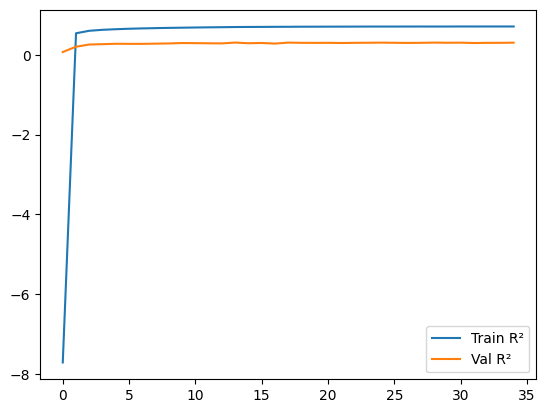

Model saved as 'pollutant_forecasting_model_lstm_optimized.keras'.
Model loaded successfully.


In [30]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
import tensorflow.keras.backend as K
import math
import matplotlib.pyplot as plt

# Load the dataset
data = pd.read_csv(r'D:\Manoj_Honors\Imputed_Predictions(Univariate,Bivariate).csv')

# Drop Null values first!
data = data.dropna()

# Drop 'Unnamed: 0' as it's just an index
data_dropped = data.drop(columns=['Unnamed: 0'])

# Convert 'Time' to datetime format and extract useful time features
data_dropped['Time'] = pd.to_datetime(data_dropped['Time'])
data_dropped['Hour'] = data_dropped['Time'].dt.hour
data_dropped['Day'] = data_dropped['Time'].dt.day
data_dropped['Month'] = data_dropped['Time'].dt.month

# Positional encoding for Latitude and Longitude
data_dropped['Lat_sin'] = np.sin(np.radians(data_dropped['Lat']))
data_dropped['Lat_cos'] = np.cos(np.radians(data_dropped['Lat']))
data_dropped['Lon_sin'] = np.sin(np.radians(data_dropped['Lon']))
data_dropped['Lon_cos'] = np.cos(np.radians(data_dropped['Lon']))

# Drop the 'Time', 'Lat', and 'Lon' columns
data_dropped = data_dropped.drop(columns=['Time', 'Lat', 'Lon'])

# Separate input features and target features
input_features = data_dropped.drop(columns=['NO2', 'PM2.5', 'Ozone'])
target_features = data_dropped[['NO2', 'PM2.5', 'Ozone']]

# Normalize input features and target features separately
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_X.fit_transform(input_features)
y_scaled = scaler_y.fit_transform(target_features)

# Combine scaled inputs and targets back for sequence splitting
data_scaled = np.hstack((X_scaled, y_scaled))

# Function to create sliding windows
def split_sequences(data, n_steps):
    X, y = [], []
    for i in range(len(data)):
        end_ix = i + n_steps
        if end_ix >= len(data):
            break
        seq_x, seq_y = data[i:end_ix, :], data[end_ix, -3:]
        X.append(seq_x)
        y.append(seq_y)
    return np.array(X), np.array(y)

# Set the number of time steps
n_steps = 4

# Split into input (X) and output (y)
X, y = split_sequences(data_scaled, n_steps)

# Split into train and validation sets (80%-20%)
train_size = int(len(X) * 0.8)
X_train, X_val = X[:train_size], X[train_size:]
y_train, y_val = y[:train_size], y[train_size:]

def r2_keras(y_true, y_pred):
    ss_res = K.sum(K.square(y_true - y_pred))
    ss_tot = K.sum(K.square(y_true - K.mean(y_true)))
    return 1 - ss_res / (ss_tot + K.epsilon())

# Build the LSTM model
model = Sequential([
    LSTM(64, activation='relu', input_shape=(X_train.shape[1], X_train.shape[2]), return_sequences=True),
    BatchNormalization(),
    Dropout(0.3),
    
    LSTM(32, activation='relu', return_sequences=True),
    BatchNormalization(),
    Dropout(0.3),
    
    LSTM(16, activation='relu'),
    BatchNormalization(),
    
    Dense(3)  # Predicting 3 outputs (NO2, PM2.5, Ozone)
])

# Compile the model
optimizer = Adam(learning_rate=1e-4)
model.compile(optimizer=optimizer, loss='mse', metrics=['mae', r2_keras])

# Callbacks for regularization
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=1)
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)

# Train the model
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=64,
    validation_data=(X_val, y_val),
    callbacks=[lr_scheduler, early_stopping],
    verbose=1
)

# Evaluate the model
y_pred = model.predict(X_val)

# Rescale predictions and true values to the original scale
y_pred_rescaled = scaler_y.inverse_transform(y_pred)
y_val_rescaled = scaler_y.inverse_transform(y_val)

# Function to calculate metrics for each pollutant
def calculate_metrics(y_true, y_pred, pollutant_name):
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = math.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    
    print(f"Metrics for {pollutant_name}:")
    print(f"MSE: {mse:.9f}")
    print(f"MAE: {mae:.9f}")
    print(f"RMSE: {rmse:.9f}")
    print(f"R²: {r2:.9f}")
    print(f"MAPE: {mape:.9f}%")
    print("-" * 40)

# Split the predictions and actual values for each pollutant
y_pred_rescaled_NO2 = y_pred_rescaled[:, 0]
y_val_rescaled_NO2 = y_val_rescaled[:, 0]

y_pred_rescaled_PM25 = y_pred_rescaled[:, 1]
y_val_rescaled_PM25 = y_val_rescaled[:, 1]

y_pred_rescaled_Ozone = y_pred_rescaled[:, 2]
y_val_rescaled_Ozone = y_val_rescaled[:, 2]

# Calculate metrics for each pollutant
calculate_metrics(y_val_rescaled_NO2, y_pred_rescaled_NO2, "NO2")
calculate_metrics(y_val_rescaled_PM25, y_pred_rescaled_PM25, "PM2.5")
calculate_metrics(y_val_rescaled_Ozone, y_pred_rescaled_Ozone, "Ozone")

# Plot training and validation R²
plt.plot(history.history['r2_keras'], label='Train R²')
plt.plot(history.history['val_r2_keras'], label='Val R²')
plt.legend()
plt.show()

# Save the model
model.save('pollutant_forecasting_model_lstm_optimized.keras')
print("Model saved as 'pollutant_forecasting_model_lstm_optimized.keras'.")

# Load the model to verify
loaded_model = load_model('pollutant_forecasting_model_lstm_optimized.keras', custom_objects={'r2_keras': r2_keras})
print("Model loaded successfully.")
  

Only PM2.5

Epoch 1/70


c:\Users\Faculty\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


28545/28545 ━━━━━━━━━━━━━━━━━━━━ 80s 3ms/step - loss: 0.0584 - mae: 0.0762 - r2_keras: -44.1788 - val_loss: 0.0014 - val_mae: 0.0279 - val_r2_keras: -0.4817 - learning_rate: 0.0010
Epoch 2/70
28545/28545 ━━━━━━━━━━━━━━━━━━━━ 77s 3ms/step - loss: 9.9257e-04 - mae: 0.0208 - r2_keras: 0.2529 - val_loss: 0.0017 - val_mae: 0.0278 - val_r2_keras: -0.3666 - learning_rate: 0.0010
Epoch 3/70
28545/28545 ━━━━━━━━━━━━━━━━━━━━ 78s 3ms/step - loss: 9.7267e-04 - mae: 0.0205 - r2_keras: 0.2581 - val_loss: 0.0014 - val_mae: 0.0284 - val_r2_keras: -0.8164 - learning_rate: 0.0010
Epoch 4/70
28545/28545 ━━━━━━━━━━━━━━━━━━━━ 83s 3ms/step - loss: 9.8321e-04 - mae: 0.0206 - r2_keras: 0.2589 - val_loss: 0.0016 - val_mae: 0.0279 - val_r2_keras: -0.3931 - learning_rate: 0.0010
Epoch 5/70
28545/28545 ━━━━━━━━━━━━━━━━━━━━ 134s 3ms/step - loss: 9.7248e-04 - mae: 0.0205 - r2_keras: 0.2654 - val_loss: 0.0015 - val_mae: 0.0289 - val_r2_keras: -0.7516 - learning_rate: 0.0010
Epoch 6/70
28545/28545 ━━━━━━━━━━━━━━━━━━━

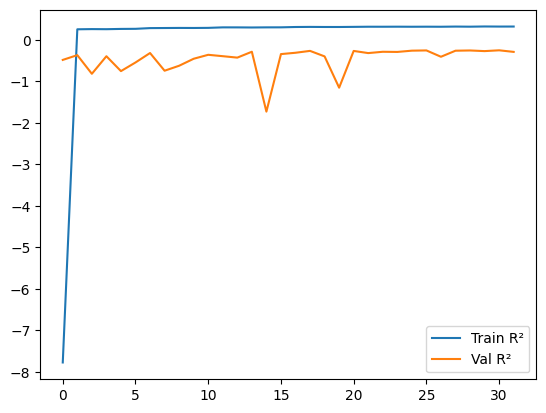

Model saved as 'Ozone_forecasting_model_lstm_optimized_with_L2_regularization.keras'.
Model loaded successfully.


In [18]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from tensorflow.keras import regularizers
import tensorflow.keras.backend as K
import math
import matplotlib.pyplot as plt

# Load the dataset
data = pd.read_csv(r'D:\Manoj_Honors\Imputed_Predictions(Univariate,Bivariate).csv')

# Drop Null values first!
data = data.dropna()

# Drop 'Unnamed: 0' as it's just an index
data_dropped = data.drop(columns=['Unnamed: 0'])

# Convert 'Time' to datetime format and extract useful time features
data_dropped['Time'] = pd.to_datetime(data_dropped['Time'])
data_dropped['Hour'] = data_dropped['Time'].dt.hour
data_dropped['Day'] = data_dropped['Time'].dt.day
data_dropped['Month'] = data_dropped['Time'].dt.month

# Positional encoding for Latitude and Longitude
data_dropped['Lat_sin'] = np.sin(np.radians(data_dropped['Lat']))
data_dropped['Lat_cos'] = np.cos(np.radians(data_dropped['Lat']))
data_dropped['Lon_sin'] = np.sin(np.radians(data_dropped['Lon']))
data_dropped['Lon_cos'] = np.cos(np.radians(data_dropped['Lon']))

# Drop the 'Time', 'Lat', and 'Lon' columns
data_dropped = data_dropped.drop(columns=['Time', 'Lat', 'Lon'])

# Separate input features and target features
input_features = data_dropped.drop(columns=['Ozone'])  # Only focus on PM2.5
target_features = data_dropped[['Ozone']]  # Target is now just Ozone

# Normalize input features and target features separately
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_X.fit_transform(input_features)
y_scaled = scaler_y.fit_transform(target_features)

# Combine scaled inputs and targets back for sequence splitting
data_scaled = np.hstack((X_scaled, y_scaled))

# Function to create sliding windows
def split_sequences(data, n_steps):
    X, y = [], []
    for i in range(len(data)):
        end_ix = i + n_steps
        if end_ix >= len(data):
            break
        seq_x, seq_y = data[i:end_ix, :], data[end_ix, -1:]  # Only predict the last column (Ozone)
        X.append(seq_x)
        y.append(seq_y)
    return np.array(X), np.array(y)

# Set the number of time steps
n_steps = 4

# Split into input (X) and output (y)
X, y = split_sequences(data_scaled, n_steps)

# Split into train and validation sets (80%-20%)
train_size = int(len(X) * 0.8)
X_train, X_val = X[:train_size], X[train_size:]
y_train, y_val = y[:train_size], y[train_size:]

# Define R² for Keras
def r2_keras(y_true, y_pred):
    ss_res = K.sum(K.square(y_true - y_pred))
    ss_tot = K.sum(K.square(y_true - K.mean(y_true)))
    return 1 - ss_res / (ss_tot + K.epsilon())

# Build the LSTM model with L2 regularizer
model = Sequential([
    LSTM(32, activation='relu', input_shape=(X_train.shape[1], X_train.shape[2]), return_sequences=True,
         kernel_regularizer=regularizers.l2(0.001)),  # L2 regularization
    BatchNormalization(),
    Dropout(0.3),
    
    LSTM(16, activation='relu', return_sequences=False, kernel_regularizer=regularizers.l2(0.001)),  # L2 regularization
    BatchNormalization(),
    Dropout(0.3),
    
    Dense(1)  # Output layer for a single value (Ozone)
])

# Compile the model
optimizer = Adam()
model.compile(optimizer=optimizer, loss='mse', metrics=['mae', r2_keras])

# Callbacks for regularization
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=1)
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)

# Train the model
history = model.fit(
    X_train, y_train,
    epochs=70,  # Reduced epochs to avoid overfitting
    batch_size=32,  # Experiment with smaller batch size
    validation_data=(X_val, y_val),
    callbacks=[lr_scheduler, early_stopping],
    verbose=1
)

# Evaluate the model
y_pred = model.predict(X_val)

# Rescale predictions and true values to the original scale
y_pred_rescaled = scaler_y.inverse_transform(y_pred)
y_val_rescaled = scaler_y.inverse_transform(y_val)

# Function to calculate metrics for Ozone
def calculate_metrics(y_true, y_pred, pollutant_name):
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = math.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    
    print(f"Metrics for {pollutant_name}:")
    print(f"MSE: {mse:.9f}")
    print(f"MAE: {mae:.9f}")
    print(f"RMSE: {rmse:.9f}")
    print(f"R²: {r2:.9f}")
    print(f"MAPE: {mape:.9f}%")
    print("-" * 40)

# Calculate metrics for Ozone
calculate_metrics(y_val_rescaled, y_pred_rescaled, "Ozone")

# Plot training and validation R²
plt.plot(history.history['r2_keras'], label='Train R²')
plt.plot(history.history['val_r2_keras'], label='Val R²')
plt.legend()
plt.show()

# Save the model
model.save('Ozone_forecasting_model_lstm_optimized_with_L2_regularization.keras')
print("Model saved as 'Ozone_forecasting_model_lstm_optimized_with_L2_regularization.keras'.")

# Load the model to verify
loaded_model = load_model('Ozone_forecasting_model_lstm_optimized_with_L2_regularization.keras', custom_objects={'r2_keras': r2_keras})
print("Model loaded successfully.")


Epoch 1/70


c:\Users\Faculty\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


28545/28545 ━━━━━━━━━━━━━━━━━━━━ 112s 4ms/step - loss: 0.0485 - mae: 0.0805 - r2_keras: -4.2636 - val_loss: 0.0022 - val_mae: 0.0264 - val_r2_keras: -0.3994 - learning_rate: 0.0010
Epoch 2/70
28545/28545 ━━━━━━━━━━━━━━━━━━━━ 77s 3ms/step - loss: 0.0029 - mae: 0.0357 - r2_keras: 0.6386 - val_loss: 0.0026 - val_mae: 0.0318 - val_r2_keras: -1.1673 - learning_rate: 0.0010
Epoch 3/70
28545/28545 ━━━━━━━━━━━━━━━━━━━━ 77s 3ms/step - loss: 0.0029 - mae: 0.0354 - r2_keras: 0.6400 - val_loss: 0.0028 - val_mae: 0.0389 - val_r2_keras: -2.5717 - learning_rate: 0.0010
Epoch 4/70
28545/28545 ━━━━━━━━━━━━━━━━━━━━ 76s 3ms/step - loss: 0.0029 - mae: 0.0353 - r2_keras: 0.6448 - val_loss: 0.0025 - val_mae: 0.0336 - val_r2_keras: -1.4908 - learning_rate: 0.0010
Epoch 5/70
28545/28545 ━━━━━━━━━━━━━━━━━━━━ 76s 3ms/step - loss: 0.0029 - mae: 0.0353 - r2_keras: 0.6446 - val_loss: 0.0027 - val_mae: 0.0322 - val_r2_keras: -1.1425 - learning_rate: 0.0010
Epoch 6/70
28544/28545 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - l

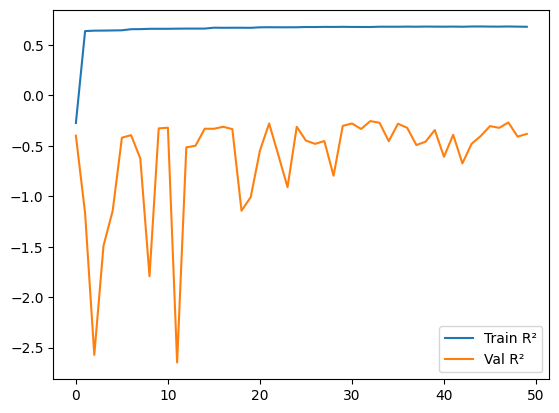

Model saved as 'PM2.5_forecasting_model_lstm_optimized_with_L2_regularization.keras'.
Model loaded successfully.


In [19]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from tensorflow.keras import regularizers
import tensorflow.keras.backend as K
import math
import matplotlib.pyplot as plt

# Load the dataset
data = pd.read_csv(r'D:\Manoj_Honors\Imputed_Predictions(Univariate,Bivariate).csv')

# Drop Null values first!
data = data.dropna()

# Drop 'Unnamed: 0' as it's just an index
data_dropped = data.drop(columns=['Unnamed: 0'])

# Convert 'Time' to datetime format and extract useful time features
data_dropped['Time'] = pd.to_datetime(data_dropped['Time'])
data_dropped['Hour'] = data_dropped['Time'].dt.hour
data_dropped['Day'] = data_dropped['Time'].dt.day
data_dropped['Month'] = data_dropped['Time'].dt.month

# Positional encoding for Latitude and Longitude
data_dropped['Lat_sin'] = np.sin(np.radians(data_dropped['Lat']))
data_dropped['Lat_cos'] = np.cos(np.radians(data_dropped['Lat']))
data_dropped['Lon_sin'] = np.sin(np.radians(data_dropped['Lon']))
data_dropped['Lon_cos'] = np.cos(np.radians(data_dropped['Lon']))

# Drop the 'Time', 'Lat', and 'Lon' columns
data_dropped = data_dropped.drop(columns=['Time', 'Lat', 'Lon'])

# Separate input features and target features
input_features = data_dropped.drop(columns=['PM2.5'])  # Only focus on PM2.5
target_features = data_dropped[['PM2.5']]  # Target is now just Ozone

# Normalize input features and target features separately
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_X.fit_transform(input_features)
y_scaled = scaler_y.fit_transform(target_features)

# Combine scaled inputs and targets back for sequence splitting
data_scaled = np.hstack((X_scaled, y_scaled))

# Function to create sliding windows
def split_sequences(data, n_steps):
    X, y = [], []
    for i in range(len(data)):
        end_ix = i + n_steps
        if end_ix >= len(data):
            break
        seq_x, seq_y = data[i:end_ix, :], data[end_ix, -1:]  # Only predict the last column (Ozone)
        X.append(seq_x)
        y.append(seq_y)
    return np.array(X), np.array(y)

# Set the number of time steps
n_steps = 4

# Split into input (X) and output (y)
X, y = split_sequences(data_scaled, n_steps)

# Split into train and validation sets (80%-20%)
train_size = int(len(X) * 0.8)
X_train, X_val = X[:train_size], X[train_size:]
y_train, y_val = y[:train_size], y[train_size:]

# Define R² for Keras
def r2_keras(y_true, y_pred):
    ss_res = K.sum(K.square(y_true - y_pred))
    ss_tot = K.sum(K.square(y_true - K.mean(y_true)))
    return 1 - ss_res / (ss_tot + K.epsilon())

# Build the LSTM model with L2 regularizer
model = Sequential([
    LSTM(32, activation='relu', input_shape=(X_train.shape[1], X_train.shape[2]), return_sequences=True,
         kernel_regularizer=regularizers.l2(0.001)),  # L2 regularization
    BatchNormalization(),
    Dropout(0.3),
    
    LSTM(16, activation='relu', return_sequences=False, kernel_regularizer=regularizers.l2(0.001)),  # L2 regularization
    BatchNormalization(),
    Dropout(0.3),
    
    Dense(1)  # Output layer for a single value (Ozone)
])

# Compile the model
optimizer = Adam()
model.compile(optimizer=optimizer, loss='mse', metrics=['mae', r2_keras])

# Callbacks for regularization
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=1)
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)

# Train the model
history = model.fit(
    X_train, y_train,
    epochs=70,  # Reduced epochs to avoid overfitting
    batch_size=32,  # Experiment with smaller batch size
    validation_data=(X_val, y_val),
    callbacks=[lr_scheduler, early_stopping],
    verbose=1
)

# Evaluate the model
y_pred = model.predict(X_val)

# Rescale predictions and true values to the original scale
y_pred_rescaled = scaler_y.inverse_transform(y_pred)
y_val_rescaled = scaler_y.inverse_transform(y_val)

# Function to calculate metrics for Ozone
def calculate_metrics(y_true, y_pred, pollutant_name):
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = math.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    
    print(f"Metrics for {pollutant_name}:")
    print(f"MSE: {mse:.9f}")
    print(f"MAE: {mae:.9f}")
    print(f"RMSE: {rmse:.9f}")
    print(f"R²: {r2:.9f}")
    print(f"MAPE: {mape:.9f}%")
    print("-" * 40)

# Calculate metrics for Ozone
calculate_metrics(y_val_rescaled, y_pred_rescaled, "Ozone")

# Plot training and validation R²
plt.plot(history.history['r2_keras'], label='Train R²')
plt.plot(history.history['val_r2_keras'], label='Val R²')
plt.legend()
plt.show()

# Save the model
model.save('PM2.5_forecasting_model_lstm_optimized_with_L2_regularization.keras')
print("Model saved as 'PM2.5_forecasting_model_lstm_optimized_with_L2_regularization.keras'.")

# Load the model to verify
loaded_model = load_model('PM2.5_forecasting_model_lstm_optimized_with_L2_regularization.keras', custom_objects={'r2_keras': r2_keras})
print("Model loaded successfully.")
